# Assignment 7
### Do any five.

## 1. 

- What is the expected value of a single die roll? 
- What is the expected value of rolling two dice and adding the results together?
- What is the expected winnings of any gamble in European roulette?

- Imagine you roll a die, and you record the value you get. But, if you roll a six, you roll again, and add that value. What is the expected value?
- Imagine that the process described in the last question continues until you fail to roll a six. What is the expected value of the process? (This can be tricky, you can simulate it to get an answer if you prefer. Hint: The answer is 4.2.)

- What is the expected value of a single die roll? 
$$
\mathbb{E}[X] = \frac{1}{6}1+\frac{1}{6}2+\frac{1}{6}3+\frac{1}{6}4+\frac{1}{6}5+\frac{1}{6}6 = \frac{21}{6}
$$

- What is the expected value of rolling two dice and adding the results together?
$$
\mathbb{E}[X] = 
\frac{1}{36}2 +
\frac{2}{36}3 +
\frac{3}{36}4 +
\frac{4}{36}5 +
\frac{5}{36}6 +
\frac{6}{36}7 +
\frac{5}{36}8 +
\frac{4}{36}9 +
\frac{3}{36}10 +
\frac{2}{36}11 +
\frac{1}{36}12 = \frac{252}{36}
$$
which is 7.

- What is the expected winnings of any gamble in European roulette?
Well, it's interesting. You pay one dollar for sure to bet on $K$ slots, and with probability $K/37$ you win and get $36/K$ dollars as payoff, but with $(37-K)/37$ you get nothing back. So the expected payoff is:
\begin{alignat*}{2}
\mathbb{E}[X] &=& \frac{K}{37}  \frac{36}{K} + \dfrac{37-K}{37}0 -1 \\
&=& \frac{36}{37} -1 \\
&=& -0.027
\end{alignat*}
So any roulette bet gives the same payoff of -.03.

- Imagine you roll a die, and you record the value you get. But, if you roll a six, you roll again, and add that value. What is the expected value?
$$
\mathbb{E}[X] = \dfrac{1}{6}1+\dfrac{1}{6}2+\dfrac{1}{6}3+\dfrac{1}{6}4+\dfrac{1}{6}5+\dfrac{1}{6}\left(6 + \dfrac{1}{6}1+\dfrac{1}{6}2+\dfrac{1}{6}3+\dfrac{1}{6}4+\dfrac{1}{6}5+\dfrac{1}{6}6 \right)
$$
Well this is 
$$
\mathbb{E}[X] = \dfrac{1}{6}1+\dfrac{1}{6}2+\dfrac{1}{6}3+\dfrac{1}{6}4+\dfrac{1}{6}5+\dfrac{1}{6}\left(6 + 3.5\right)
$$
or
$$
\mathbb{E}[X] = 3.5+\dfrac{3.5}{6} = \frac{24.5}{6} \approx 4.083
$$

- Imagine that the process described in the last question continues until you fail to roll a six. What is the expected value of the process? (This can be tricky, you can simulate it to get an answer if you prefer. Hint: The answer is 4.2.)

You can definitely simulate this, but the cute way to handle this is to recognize that it recurses on itself: If you roll a 6, you get 6 + "do it again". Let's call "do it again" the value $J$. Then
$$
J = \dfrac{1}{6}1+\dfrac{1}{6}2+\dfrac{1}{6}3+\dfrac{1}{6}4+\dfrac{1}{6}5+\dfrac{1}{6}(6 + J)
$$
or
$$
J = \frac{21}{6} + \frac{1}{6}J
$$
or
$$
J = \dfrac{21}{5} \approx 4.2
$$
So, in expectation, goes from about 3.5 for a single die roll to 4.2 for the process. Let's simulate:

Simulated value of the process: 4.19602


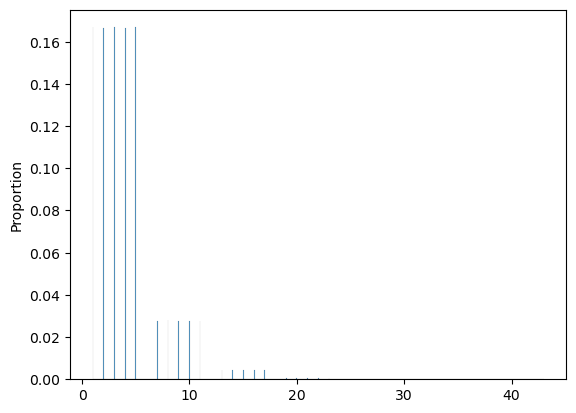

In [1]:
import numpy as np
import seaborn as sns

rng = np.random.default_rng(100)

def simulate():
    sum = 0
    on = 1
    while on == 1:
        roll = rng.integers(1,7)
        sum += roll
        if( roll < 6 ):
            on = 0
    return sum

n_sample = 1000000
results = [simulate() for i in range(n_sample)]

sns.histplot(results,stat='proportion')

print(f'Simulated value of the process: {np.mean(results)}')


So we get approximately the same answer.

## 2. 
- Compute the expected value for a uniform random variable.
We have to solve
$$
\int_0^1 x \times 1 dx =  \int_0^1 d \left\lbrace \frac{1}{2} x^2 \right\rbrace = \frac{1}{2}1^2 - \frac{1}{2}0^2 = \frac{1}{2}
$$
- Show that $\mathbb{E}[a+bX] = a + b\mathbb{E}[X]$
This is basically a property of the integral:
$$
\mathbb{E}[a+bX] = \int_{-\infty}^{+\infty} (a + bx)f(x)dx = \int_{-\infty}^{+\infty} af(x) + bxf(x)dx = a \int_{-\infty}^{+\infty} f(x)dx + b \int_{-\infty}^{+\infty} xf(x)dx =a + b \mathbb{E}[X]
$$
since $ \int_a^b f(x) dx = F(b) - F(a)$, and $F(-\infty)=0$ and $F(+\infty)=1$.


- Show, by example, that $v(\mathbb{E}[X]) \neq \mathbb{E}[v(X)]$, if $v(x) \neq a+bx$. For example, try $v(y) = y^2$ or $v(y)=\sqrt{y}$ with a Bernoulli or uniform or normally distributed random variable. This can be an important thing to remember: The expectation of a transformed random variable is not the transformation of the expected value.

Expected Value: 0.6702156959662173
Value of Expectation: 0.7102554079580381


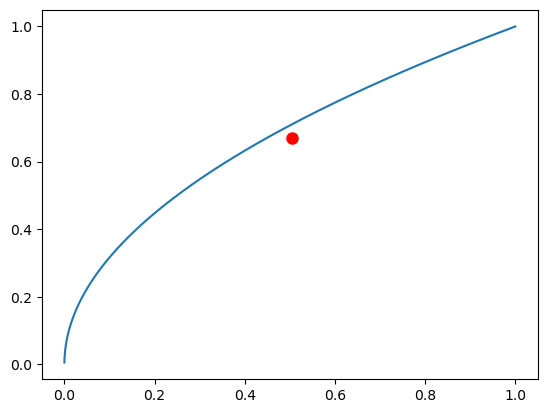

In [2]:
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

def v(x):
    return np.sqrt(x)

sample = np.random.uniform(low=0, high=1,size = 20000)

Ev_of_sample = np.mean( v(sample) )
print(f'Expected Value: {Ev_of_sample}')

v_of_EX = v(np.mean(sample))
print(f'Value of Expectation: {v_of_EX}')

sns.lineplot(x=sample, y=v(sample))
plt.plot(np.mean(sample),Ev_of_sample, 'o', color='red', markersize=8)


## 8.
- Open the METABRIC data. Make a histogram of 'Ratio Therapy'.
- Let treatment, $T$ be distributed binomial with parameter $p$. Then the contribution to the likelihood for each patient $i$, with $y_i = 0$ for no radiation therapy and $y_i=1$ for radiation therapy, is 
$$
p^{y_i}(1-p)^{1-y_i}
$$
- Write out the likelihood.
- Maximize the likelihood with respect to $p$. What is the MLE, $\hat{p}$?
- Bootstrap the sampling density/distribution of $\hat{p}$.

<Axes: xlabel='Radio Therapy', ylabel='Proportion'>

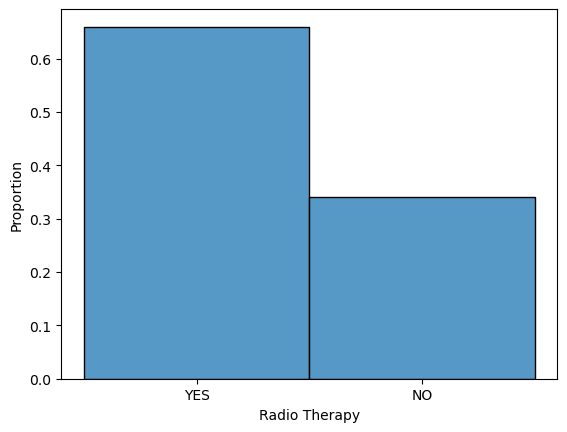

In [5]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy as sp 

df = pd.read_csv('metabric.csv')

y = df['Radio Therapy']
sns.histplot(y,stat='proportion')

The likelihood is 
$$
L(p) = \prod_{i=1}^n p^{y_i}(1-p)^{1-y_i}
$$

To maximize, we first take logs:
$$
\ell(p) = \sum_{i=1}^n y_i \log(p) + (1-y_i) \log(1-p)
$$
and
$$
\ell'(p) = \sum_{i=1}^n y_i \frac{1}{p} - (1-y_i) \frac{1}{1-p}
$$
At the optimum, we have
$$
\sum_{i=1}^n y_i \frac{1}{\hat{p}} - (1-y_i) \frac{1}{1-\hat{p}} = 0
$$
Solving the first-order condition for $p$ yields the MLE
$$
\hat{p} = \dfrac{1}{n} \sum_{i=1}^n y_i.
$$

MLE:  0.659717051377513


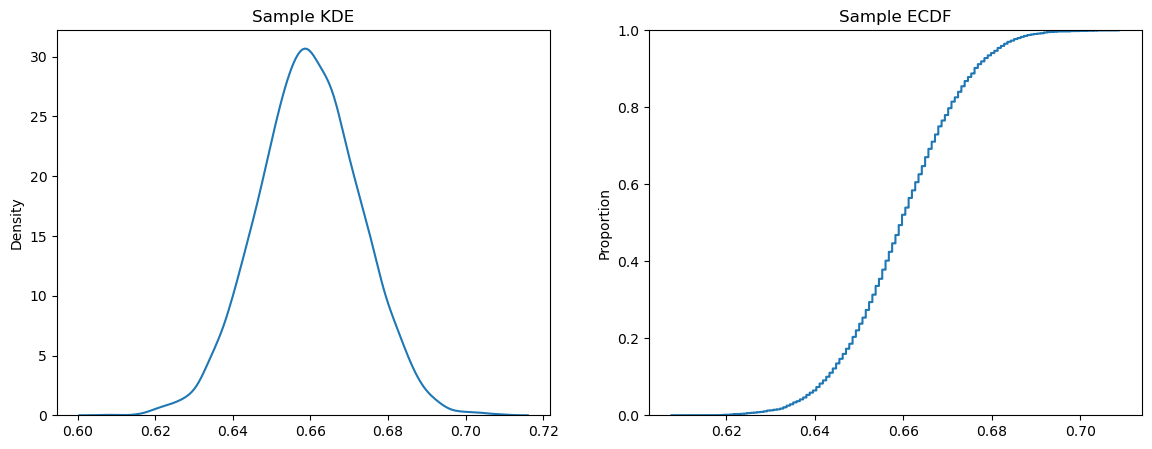

In [ ]:
y = pd.to_numeric( y.replace({'NO':'0','YES':'1'}) , errors='coerce' ) # Convert string to numeric
print(f'MLE: ', y.mean())

S = 5000
sample = [ np.mean( y.sample(frac=1,replace=True) ) for s in range(S) ]

fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.kdeplot(x=sample,ax=axes[0],label='kde')
axes[0].set_title('Sample KDE')
sns.ecdfplot(x=sample,ax=axes[1],label='ecdf')
axes[1].set_title('Sample ECDF')
plt.show()

## 9.
- Open the Ames house price data. Make a KDE of 'price'. Select an appropriate distribution for modeling it, and explain why you selected it. (Hint: You might want to take a common transformation of price.)
- Derive the density for this distribution.
- Write out the likelihood.
- Maximize the likelihood. What is the MLE?
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameters.

<Axes: xlabel='price', ylabel='Proportion'>

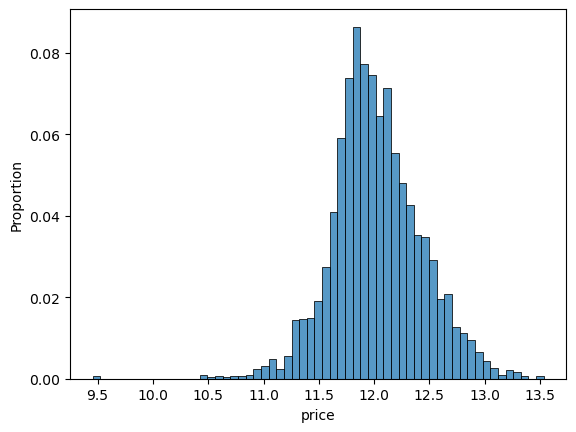

In [7]:
df = pd.read_csv('ames_prices.csv')
y = np.log( df['price'] )
sns.histplot(y,stat='proportion')

After taking logs, this looks reasonably symmetric and bell-shaped around 12, so I'm going to model $\log(\text{price})$ as normal with mean $\mu$ and standard deviation $\sigma$. This means price is log-normally distributed, but we're going to focus on the logged version for the exercise.

Our density is
$$
f(y) = \dfrac{1}{\sqrt{2\pi} \sigma}e^{-\frac{1}{2}\left( \frac{y-\mu}{\sigma} \right)^2}
$$
and the likelihood is
$$
L(\mu, \sigma) = \prod_{i=1}^n \dfrac{1}{\sqrt{2\pi} \sigma}e^{-\frac{1}{2}\left( \frac{y_i-\mu}{\sigma} \right)^2}.
$$

To maximize the likelihood, we first take logs:
$$
\ell(\mu, \sigma) = \sum_{i=1}^n \log \left( \dfrac{1}{\sqrt{2\pi}}\right) - \log(\sigma) -\frac{1}{2}\left( \frac{y_i-\mu}{\sigma} \right)^2
$$
We then take the derivative with respect to each parameter:
$$
\dfrac{\partial \ell(\mu,\sigma)}{\partial \mu} = \sum_{i=1}^n  \frac{y_i-\mu}{\sigma^2}
$$
$$
\dfrac{\partial \ell(\mu,\sigma)}{\partial \sigma} = \sum_{i=1}^n  \frac{-1}{\sigma} +  \frac{(y_i-\mu)^2}{\sigma^3} 
$$
Setting these equal to zero and solving yields
$$
\hat{\mu} = \frac{1}{n}\sum_{i=1}^n y_i
$$
$$
\hat{\sigma} = \sqrt{ \frac{1}{n} \sum_{i=1}^n (y_i - \hat{\mu})^2 }
$$
So now, we have a fitted model: $y \sim N(\hat{\mu}, \hat{\sigma})$. Is it good? Does it fit?

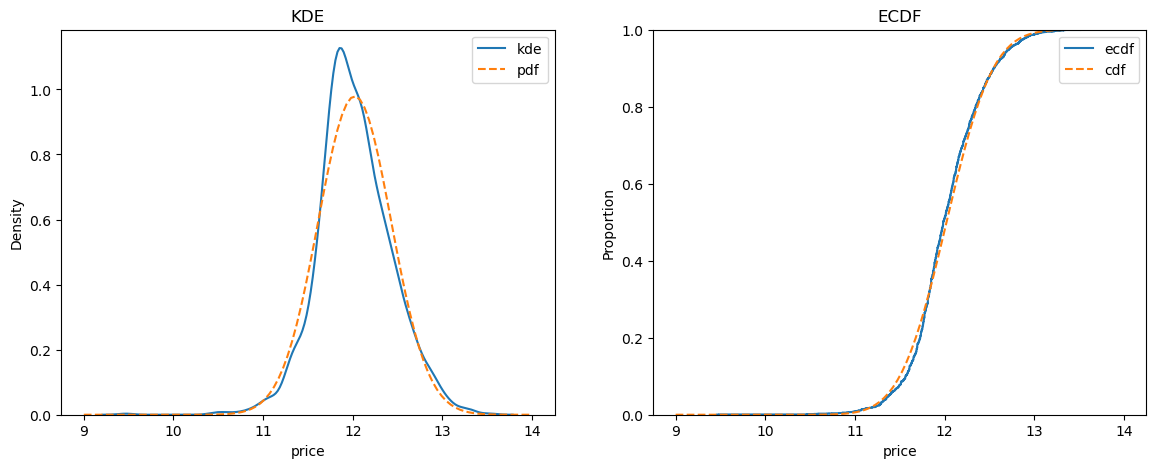

In [ ]:
mu_hat = np.mean(y)
sigma_hat = np.sqrt( np.mean( (y-mu_hat)**2 ) )

grid = np.linspace(9,14,100)

pdf = sp.stats.norm.pdf(grid,loc=mu_hat,scale=sigma_hat)
cdf = sp.stats.norm.cdf(grid,loc=mu_hat,scale=sigma_hat)

fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.kdeplot(x=y,ax=axes[0],label='kde')
sns.lineplot(x=grid,y=pdf,ax=axes[0],label='pdf',linestyle='--')
axes[0].set_title('KDE')
sns.ecdfplot(x=y,ax=axes[1],label='ecdf')
sns.lineplot(x=grid,y=cdf,ax=axes[1],label='cdf',linestyle='--')
axes[1].set_title('ECDF')
plt.show()

The fit of the ECDF looks rather good: The lines are right on top of one another. For the pdf, the data have a higher peak and seem to have a bit of left-ward skew. But they're bell-shaped and their tails die off rather quickly. A more formal approach to this would be to make a Quantile-Quantile plot to compare the distributions or a Kolmogorov-Smirnoff test of equality, but that's a little much for the moment.

Let's look at the sampling distribution of $\hat{\mu}$ and $\hat{\sigma}$.

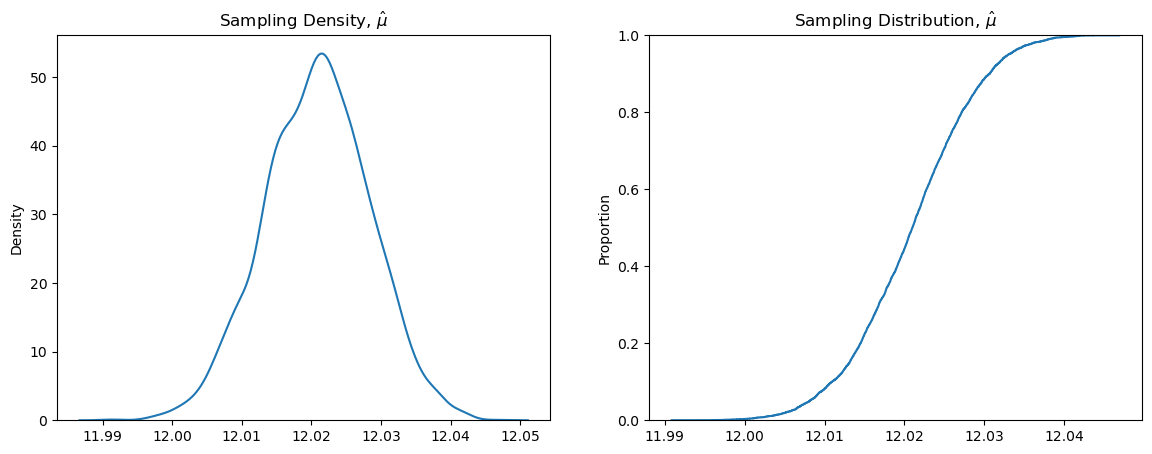

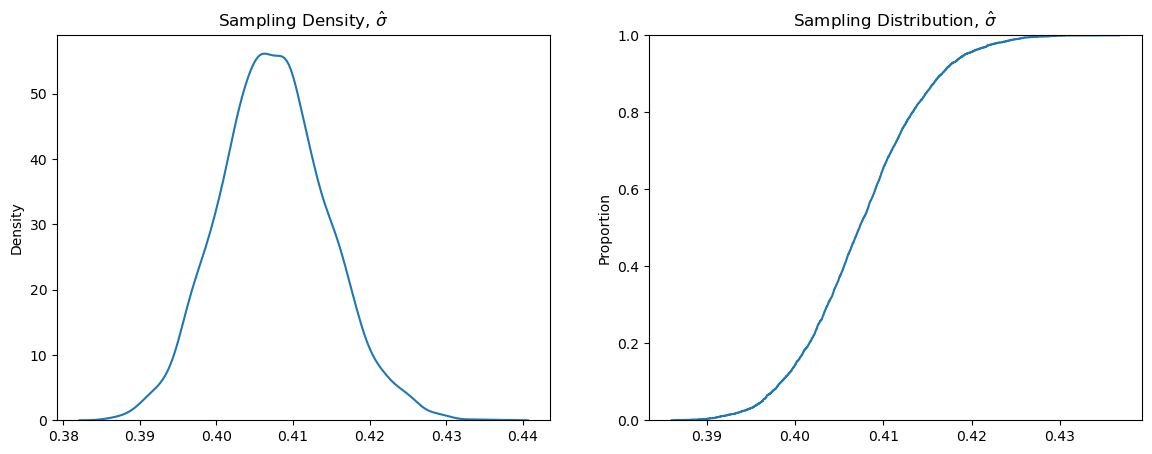

In [ ]:
# Estimation:
def mle(y):
    mu_hat = np.mean(y)
    sigma_hat = np.sqrt( np.mean( (y-mu_hat)**2 ) )
    return mu_hat, sigma_hat

# Bootstrapping:
S = 5000
sample = [ mle(y.sample(frac=1.0,replace=True)) for s in range(S)]

# Sampling distributions:
mu_hat_sample = [ row[0] for row in sample]
fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.kdeplot(x=mu_hat_sample,ax=axes[0],label='kde')
axes[0].set_title('Sampling Density, $\\hat{\\mu}$')
sns.ecdfplot(x=mu_hat_sample,ax=axes[1],label='ecdf')
axes[1].set_title('Sampling Distribution, $\\hat{\\mu}$')
plt.show()

sigma_hat_samples = [ row[1] for row in sample]
fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.kdeplot(x=sigma_hat_samples,ax=axes[0],label='kde')
axes[0].set_title('Sampling Density, $\\hat{\\sigma}$')
sns.ecdfplot(x=sigma_hat_samples,ax=axes[1],label='ecdf')
axes[1].set_title('Sampling Distribution, $\\hat{\\sigma}$')
plt.show()

This is great! We now have a completely fitted model, including the ability simulate it with $N(\hat{\mu},\hat{\sigma})$ (first-order uncertainty) and conduct inference on its sampling distribution (second-order uncertainty).

## 10.
- Open the METABRIC data. Make a KDE of 'Overall Survival (Months)'.
- Let survival time, $T$ be distributed exponentially with parameter $\lambda$. Then its distribution is
$$
F(t) = 1 - e^{-\lambda t} = p[T\le t].
$$
- Derive the density for this distribution.
- Write out the likelihood.
- Maximize the likelihood with respect to $\lambda$. What is the MLE, $\hat{\lambda}$?
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of $\hat{\lambda}$.

<Axes: xlabel='Overall Survival (Months)', ylabel='Proportion'>

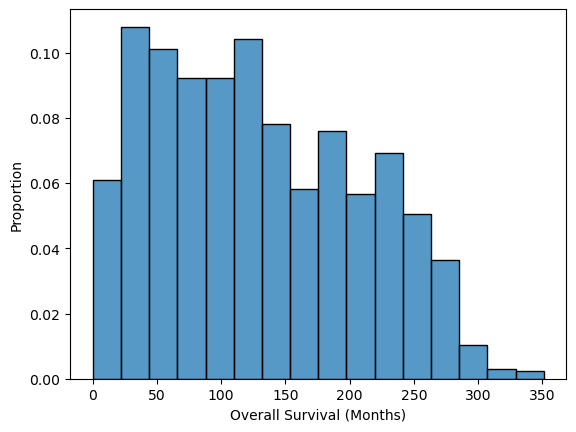

In [8]:
data = pd.read_csv('metabric.csv')
# make a kde of 'overall survival (months)'
y = data['Overall Survival (Months)']
sns.histplot(y,stat='proportion')

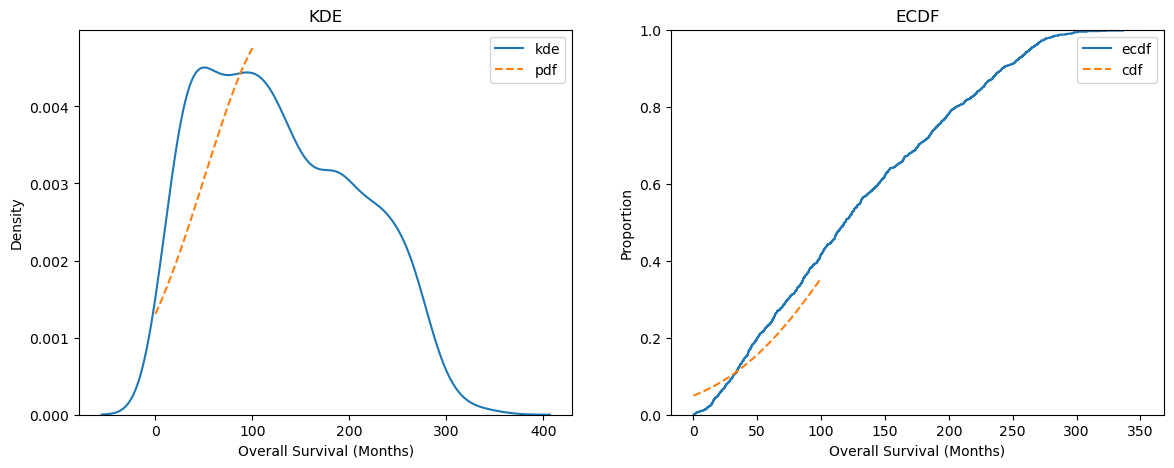

In [10]:
# derive the density for this distribution
mu_hat = np.mean(y)
sigma_hat = np.sqrt( np.mean( (y-mu_hat)**2 ) )

grid = np.linspace(0,100,100)

pdf = sp.stats.norm.pdf(grid,loc=mu_hat,scale=sigma_hat)
cdf = sp.stats.norm.cdf(grid,loc=mu_hat,scale=sigma_hat)

fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.kdeplot(x=y,ax=axes[0],label='kde')
sns.lineplot(x=grid,y=pdf,ax=axes[0],label='pdf',linestyle='--')
axes[0].set_title('KDE')
sns.ecdfplot(x=y,ax=axes[1],label='ecdf')
sns.lineplot(x=grid,y=cdf,ax=axes[1],label='cdf',linestyle='--')
axes[1].set_title('ECDF')
plt.show()

In [14]:
# maximize the likelihood with respect to lambda
def neg_log_likelihood(lam, data):
    n = len(data)
    return n * np.log(lam) - lam * np.sum(data)

In [15]:
# what is the MLE lamdba_hat
lambda_hat = mle(y)
print(f'MLE lambda: {lambda_hat}')

MLE lambda: 0.007746275913926935


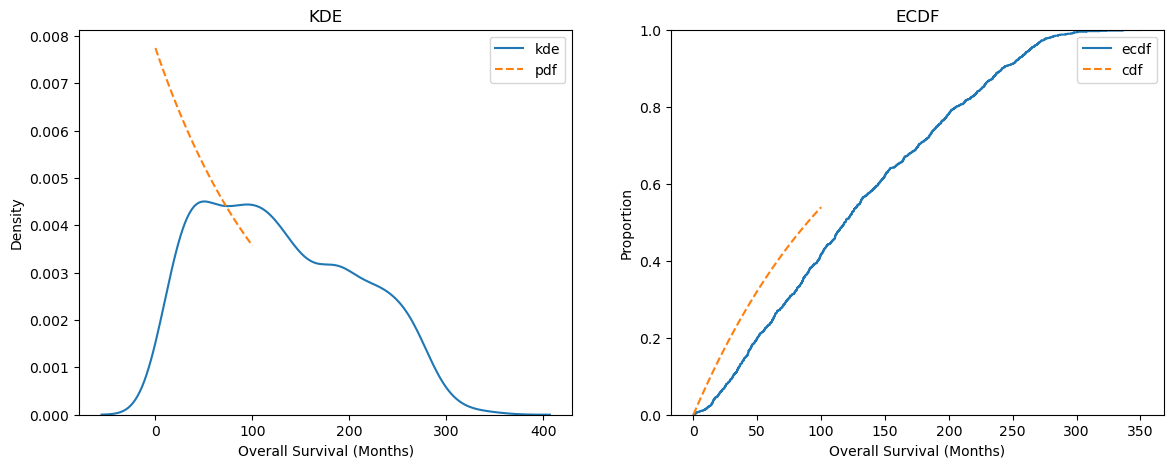

In [ ]:
# plot the density and distribution for fitted model
grid = np.linspace(0,100,100)
pdf = lambda_hat * np.exp( -lambda_hat * grid )
cdf = 1 - np.exp( -lambda_hat * grid )

fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.kdeplot(x=y,ax=axes[0],label='kde')
sns.lineplot(x=grid,y=pdf,ax=axes[0],label='pdf',linestyle='--')
axes[0].set_title('KDE')
sns.ecdfplot(x=y,ax=axes[1],label='ecdf')
sns.lineplot(x=grid,y=cdf,ax=axes[1],label='cdf',linestyle='--')
axes[1].set_title('ECDF')
plt.show()